### Import Dependencies

In [2]:
import os
import re
import json
from glob import glob
from collections import defaultdict
from multiprocessing import Pool, cpu_count

from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from mplsoccer import Pitch

### Data Preprocessing

**PPDA** (*Passes allowed Per Defensive Action*), introduced by Colin Trainor, is the standard proxy for **pressing intensity**. A side that presses aggressively forces its opponent to give the ball up after only a handful of passes; a side that sits in a deep block lets the opponent circulate it freely.

$$
\text{PPDA} = \frac{\text{opponent passes}}{\text{tackles} + \text{interceptions} + \text{challenges} + \text{fouls}}
$$

A **lower** PPDA means a **more intense** press. Both quantities are counted only in the **opponent's defensive 60%** of the pitch — the build-up zone where pressing actually happens — so the metric is not diluted by passes knocked around inside the opponent's own final third.

A common misconception is that PPDA needs a dedicated *"pressure"* event. It does not. The denominator is built entirely from four ordinary defensive actions, all of which the **Opta MA3dp** feed records directly:

| Action | Opta `typeId` | Note |
|---|---|---|
| Pass | `1` | the numerator |
| Tackle | `7` | a player dispossesses an opponent |
| Interception | `8` | a pass is cut out |
| Challenge | `45` | an *unsuccessful* tackle (opponent dribbles past) |
| Foul | `4` | only the **committed** side, `outcome = 0` |

(See `docs/opta_ma3dp_reference.md` for the full `typeId` / `qualifierId` dictionary.)

In [3]:
PASS_TYPE = 1

# Defensive actions forming the PPDA denominator (Opta typeIds).
TYPE_TACKLE = 7
TYPE_INTERCEPTION = 8
TYPE_CHALLENGE = 45       # an unsuccessful tackle attempt
TYPE_FOUL = 4             # logged for both teams; outcome 0 == foul committed

SIMPLE_DEF_TYPES = {TYPE_TACKLE, TYPE_INTERCEPTION, TYPE_CHALLENGE}
KEEP_TYPES = {PASS_TYPE, TYPE_FOUL} | SIMPLE_DEF_TYPES


def load_events(f):
    """
    Read a single Opta MA3dp file and keep only the events PPDA needs.

    The event stream lives at content -> liveData -> matchDetails -> event.
    Every event carries a contestantId (the team UUID) and an x coordinate
    (0 = own goal line, 100 = opponent goal line).
    """
    with open(f, "r") as fp:
        raw = json.load(fp)

    events = raw["content"]["liveData"]["matchDetails"]["event"]
    match_id = os.path.basename(f).replace(".json", "")

    records = []
    for e in events:
        t = e.get("typeId")
        cid = e.get("contestantId")
        x = e.get("x")
        if cid is None or x is None or t not in KEEP_TYPES:
            continue
        records.append(
            {
                "match_id": match_id,
                "contestant_id": cid,
                "type_id": t,
                "outcome": e.get("outcome"),
                "x": x,
                "y": e.get("y"),
            }
        )
    return pd.DataFrame(records)

Unlike a single richly-annotated file, most fixtures in this feed ship only the `liveData` block — there is **no `matchInfo`**, so the events expose the team **UUID** but not the team **name**. The matchup is, however, encoded in the filename (e.g. `20260620巴西vs海地` → *Brazil vs Haiti*).

We can therefore recover every team's identity globally: a UUID's nation is the **name token common to every filename it appears in**. A team that plays several different opponents intersects down to exactly one token; the rare ambiguous case falls back to a short id.

In [4]:
def filename_tokens(match_id):
    """Strip the leading yyyymmdd and split 'HOMEvsAWAY' into the two names."""
    stem = re.sub(r"^\d{8}", "", match_id)
    return set(stem.split("vs"))


def resolve_team_names(events):
    """Map each contestant UUID to its nation via filename intersection."""
    mapping = {}
    for cid, grp in events.groupby("contestant_id"):
        token_sets = [filename_tokens(m) for m in grp["match_id"].unique()]
        common = set.intersection(*token_sets)
        mapping[cid] = common.pop() if len(common) == 1 else cid[:6]
    return mapping

We use multiprocessing to speed up the ingestion of JSON files into a unified DataFrame.

In [5]:
event_files = glob(
    "/home/liyi/Documents/project_kick/kick_lab/football_coach/pitch_pilot/data/*.json"
)

with Pool(cpu_count()) as pool:
    filtered_list = list(
        tqdm(pool.imap(load_events, event_files),
             total=len(event_files),
             desc="Loading Matches")
    )

events = pd.concat(filtered_list, ignore_index=True)

# Attach human-readable team names recovered from the filenames.
events["team"] = events["contestant_id"].map(resolve_team_names(events))

print(f"Loaded {len(events):,} events from {events['match_id'].nunique():,} matches "
      f"across {events['team'].nunique()} teams")

Loading Matches: 100%|██████████| 73/73 [00:00<00:00, 400.18it/s]


Loaded 163,010 events from 73 matches across 48 teams


### Helper Functions

Opta MA3dp uses a **normalized pitch** scaled to `100 × 100`:

- `x = 0` is always the team's **own** goal line, `x = 100` the **opponent's** goal line.
- `y = 0` is one touchline, `y = 100` the other.
- Coordinates are stored **as if every team attacks left → right**, in both halves.

Because of this normalization, a team's own goal is *always* at `x = 0` regardless of which way it is physically kicking, which lets us define a single "build-up zone" without tracking sides.

In [6]:
PITCH_LENGTH = 100.0   # Opta x
PITCH_WIDTH = 100.0    # Opta y

# PPDA zone: exclude the pressing team's own defensive 40% of the pitch.
DEF_ZONE_FRACTION = 0.40
DEF_ACTION_MIN_X = DEF_ZONE_FRACTION * PITCH_LENGTH          # 40.0
PASS_MAX_X = PITCH_LENGTH - DEF_ACTION_MIN_X                 # 60.0

The press happens in one physical band — the opponent's defensive 60% — but the two teams see it through **mirrored coordinate frames**, because each is normalized to attack towards `x = 100`.

- For the **pressing** team, that band is high up the pitch: a defensive action counts when its `x > 40` (the team's attacking 60%).
- For the team **being pressed**, the *same band* is its own build-up area: a pass counts when its `x < 60`.

$$
x_{\text{press}} \;=\; 100 - x_{\text{opponent}}
$$

A tackle at `x = 40` for the presser and an opponent pass at `x = 60` therefore sit at exactly the same spot on the grass. Restricting both counts to this band is what makes PPDA a measure of *high* pressing rather than generic defending.

In [7]:
def flag_ppda_events(df):
    """
    Tag each retained event as an in-zone pass or an in-zone defensive action.

    A Foul (typeId 4) is logged for both teams; only the committing side
    (outcome 0) actually performed a defensive action.
    """
    is_def_action = (
        df["type_id"].isin(SIMPLE_DEF_TYPES)
        | ((df["type_id"] == TYPE_FOUL) & (df["outcome"] == 0))
    )
    is_pass = df["type_id"] == PASS_TYPE

    df = df.copy()
    df["pass_in_zone"] = is_pass & (df["x"] < PASS_MAX_X)
    df["def_action_in_zone"] = is_def_action & (df["x"] > DEF_ACTION_MIN_X)
    return df


events = flag_ppda_events(events)
print(f"In-zone passes            : {events['pass_in_zone'].sum():,}")
print(f"In-zone defensive actions : {events['def_action_in_zone'].sum():,}")

In-zone passes            : 71,031
In-zone defensive actions : 18,422


### Computing PPDA

PPDA is a **per-team, per-match** quantity. For each match we attribute every **in-zone pass** to the team that made it and every **in-zone defensive action** to the team that performed it. A team's denominator is its *own* defensive actions; its numerator is the passes played by *its opponent in that match*.

In [8]:
def match_team_counts(events):
    """Aggregate in-zone passes and defensive actions to (match, team)."""
    return (
        events
        .groupby(["match_id", "team"])
        .agg(
            passes=("pass_in_zone", "sum"),
            def_actions=("def_action_in_zone", "sum"),
        )
        .reset_index()
    )


team_match = match_team_counts(events)
team_match.head()

,match_id,team,passes,def_actions
0,20221218阿根廷vs法国,法国,416,33
1,20221218阿根廷vs法国,阿根廷,468,36
2,20260612墨西哥vs南非,南非,484,178
3,20260612墨西哥vs南非,墨西哥,614,190
4,20260612韩国vs捷克,捷克,387,172


Within a match there are exactly two teams, so a team's **opponent passes** is simply *the total passes in the match minus its own*. PPDA is then the opponent's passes divided by the team's own defensive actions.

In [9]:
match_passes = team_match.groupby("match_id")["passes"].transform("sum")
team_match["opp_passes"] = match_passes - team_match["passes"]

team_match["ppda"] = team_match["opp_passes"] / team_match["def_actions"]
team_match = team_match.replace([np.inf, -np.inf], np.nan).dropna(subset=["ppda"])

team_match[["match_id", "team", "opp_passes", "def_actions", "ppda"]].head(10)

,match_id,team,opp_passes,def_actions,ppda
0,20221218阿根廷vs法国,法国,468,33,14.181818
1,20221218阿根廷vs法国,阿根廷,416,36,11.555556
2,20260612墨西哥vs南非,南非,614,178,3.449438
3,20260612墨西哥vs南非,墨西哥,484,190,2.547368
4,20260612韩国vs捷克,捷克,593,172,3.447674
5,20260612韩国vs捷克,韩国,387,101,3.831683
6,20260613加拿大vs波黑,加拿大,397,149,2.664430
7,20260613加拿大vs波黑,波黑,488,146,3.342466
8,20260613美国vs巴拉圭,巴拉圭,615,165,3.727273
9,20260613美国vs巴拉圭,美国,600,175,3.428571


A single match is noisy — a side chasing a game, or protecting a lead, distorts a one-off number. To describe a team's **pressing identity** we pool every match it played and compute a weighted PPDA: total opponent passes divided by total defensive actions across all its matches. We require a minimum number of matches so the ranking is not driven by tiny samples.

In [10]:
MIN_MATCHES = 3

team_season = (
    team_match
    .groupby("team")
    .agg(
        matches=("match_id", "nunique"),
        opp_passes=("opp_passes", "sum"),
        def_actions=("def_actions", "sum"),
    )
    .reset_index()
)
team_season["ppda"] = team_season["opp_passes"] / team_season["def_actions"]
team_season = team_season[team_season["matches"] >= MIN_MATCHES]
team_season = team_season.sort_values("ppda").reset_index(drop=True)

print(f"{len(team_season)} teams with >= {MIN_MATCHES} matches")
team_season.head(15)

48 teams with >= 3 matches


,team,matches,opp_passes,def_actions,ppda
0,厄瓜多尔,3,1422,670,2.122388
1,土耳其,3,1256,508,2.472441
2,葡萄牙,3,1123,454,2.473568
3,英格兰,3,1135,453,2.505519
4,德国,3,1417,507,2.794872
5,西班牙,3,1279,438,2.920091
6,加拿大,3,1195,408,2.928922
7,海地,3,1717,571,3.007005
8,美国,3,1597,529,3.018904
9,挪威,3,1325,430,3.081395


The chart below ranks the **most aggressive pressing sides** (lowest PPDA). Possession-dominant teams typically sit at the top: by keeping the ball they both deny the opponent passes (shrinking the numerator) and win it back high up the pitch the moment they lose it (inflating the denominator).

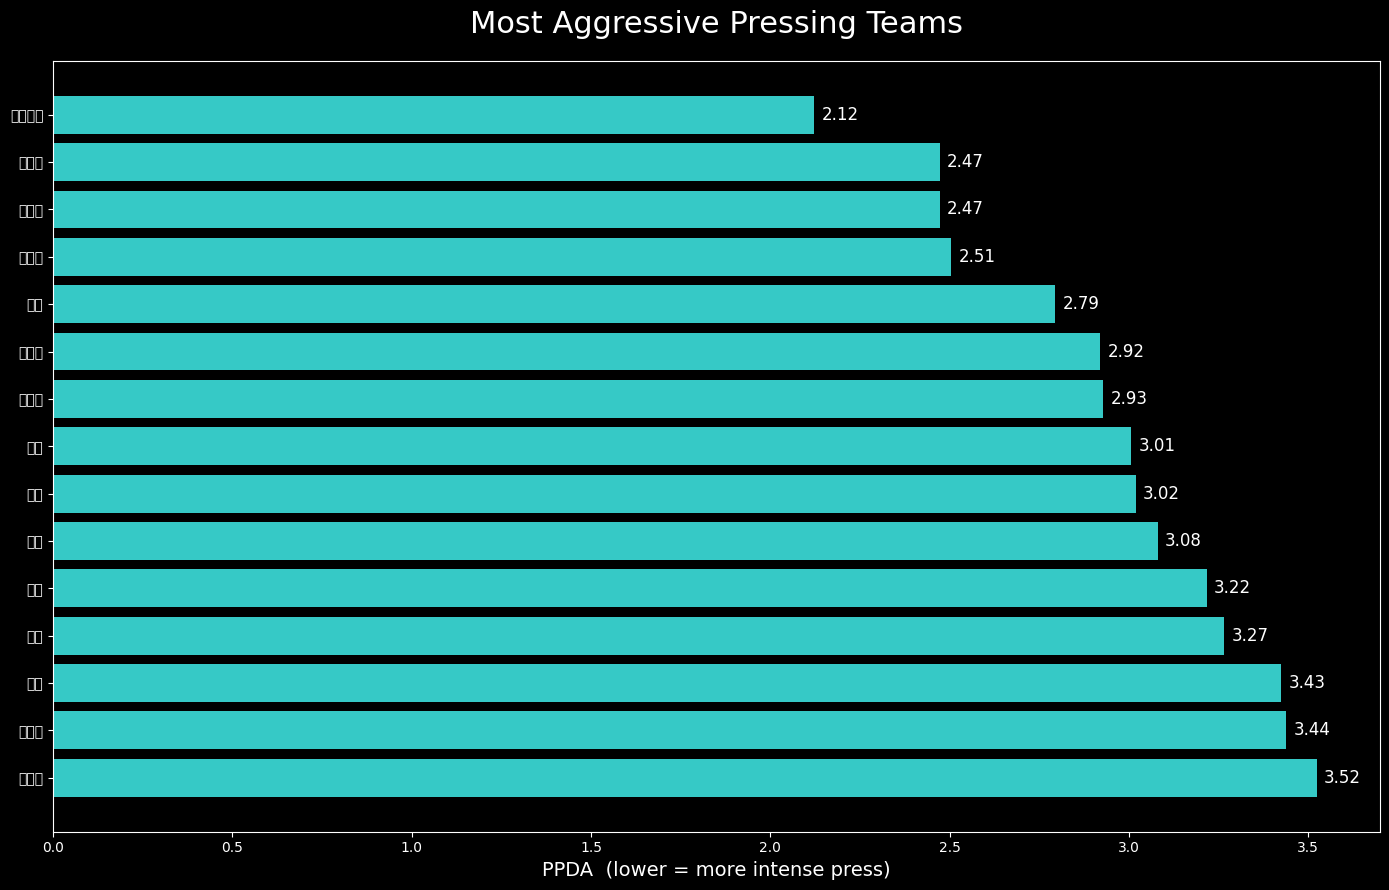

In [11]:
top_press = team_season.nsmallest(15, "ppda")

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14, 9))

ax.barh(top_press["team"], top_press["ppda"], color="#36c9c6")
ax.invert_yaxis()
ax.set_xlabel("PPDA  (lower = more intense press)", fontsize=14)
ax.set_title("Most Aggressive Pressing Teams", fontsize=22, pad=20)

for y, v in enumerate(top_press["ppda"]):
    ax.text(v + 0.02, y, f"{v:.2f}", va="center", fontsize=12)

plt.tight_layout()
plt.show()

### Where Teams Press

PPDA collapses pressing into a single number, but *where* a team applies its defensive actions is just as telling. Plotting their spatial density shows whether a side hunts the ball in the **opponent's final third**, screens the **middle third**, or only defends the edge of its own block.

The heatmap bins every in-zone defensive action onto an Opta `100 × 100` pitch. We highlight the most aggressive presser from the ranking above; change `team` to inspect any other side.

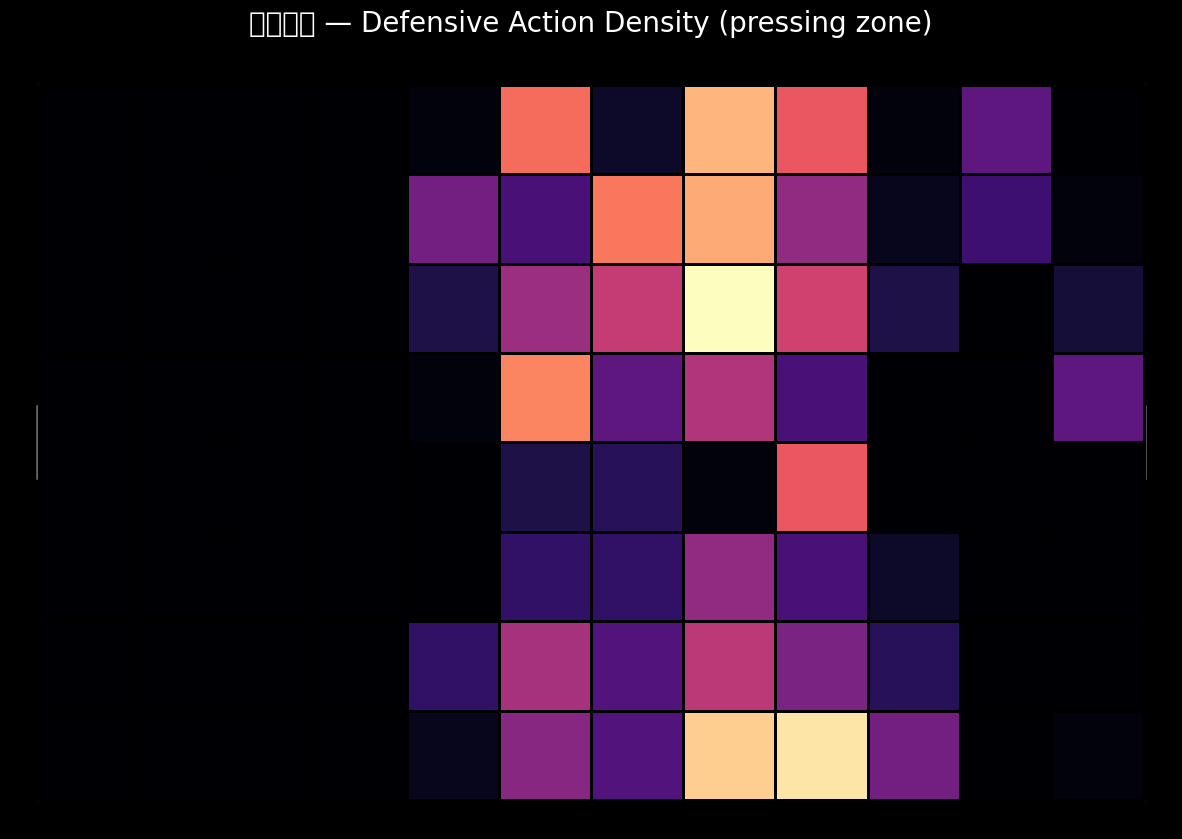

In [12]:
team = team_season.iloc[0]["team"]

acts = events[(events["def_action_in_zone"]) & (events["team"] == team)]

pitch = Pitch(pitch_type="opta", pitch_color="black", line_color="#666666")
fig, ax = pitch.draw(figsize=(13, 8.5))
fig.patch.set_facecolor("black")

bin_stat = pitch.bin_statistic(
    acts["x"], acts["y"], statistic="count", bins=(12, 8)
)
pitch.heatmap(bin_stat, ax=ax, cmap="magma", edgecolors="black")

ax.set_title(
    f"{team} — Defensive Action Density (pressing zone)",
    fontsize=20, color="white", pad=18,
)
plt.show()

Read the other way round, the **distribution of PPDA across all teams** shows how the field splits between high-pressing and deep-block approaches. Most teams cluster in a middle band, with thin tails of extreme pressers and of sides that rarely engage high up the pitch.

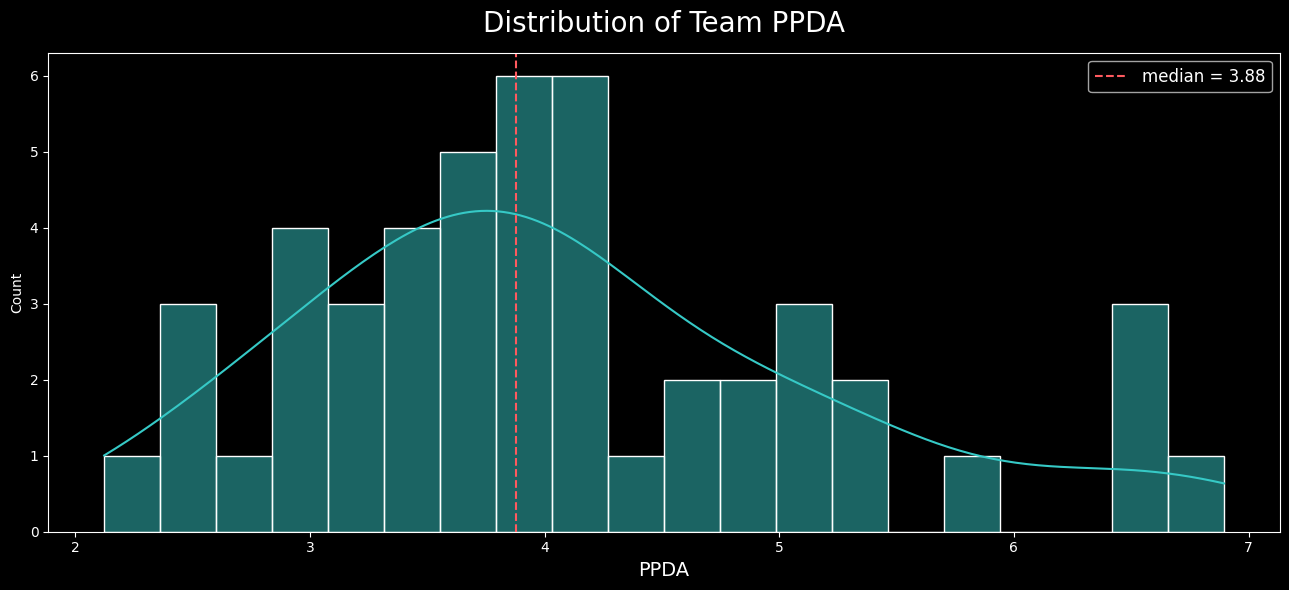

In [13]:
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(13, 6))

sns.histplot(team_season["ppda"], bins=20, kde=True, color="#36c9c6", ax=ax)
ax.axvline(team_season["ppda"].median(), color="#ff5a5f", linestyle="--",
           label=f"median = {team_season['ppda'].median():.2f}")
ax.set_xlabel("PPDA", fontsize=14)
ax.set_title("Distribution of Team PPDA", fontsize=20, pad=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Worked Example: One Match

Finally, a single-match sanity check. We pick one fixture and print PPDA for both sides together with the raw counts behind each value — the clearest way to confirm the pipeline behaves: the side that dominates the ball should post a low PPDA, while an opponent defending in a deep block posts a high one.

In [14]:
def ppda_for_match(match_id):
    rows = team_match[team_match["match_id"] == match_id]
    print(f"PPDA — {match_id}  (lower = more intense press)")
    for _, r in rows.iterrows():
        print(
            f"  {r['team']:<12} PPDA={r['ppda']:6.2f}  "
            f"(opp passes={int(r['opp_passes'])}, def actions={int(r['def_actions'])})"
        )


ppda_for_match(team_match["match_id"].iloc[0])

PPDA — 20221218阿根廷vs法国  (lower = more intense press)
  法国           PPDA= 14.18  (opp passes=468, def actions=33)
  阿根廷          PPDA= 11.56  (opp passes=416, def actions=36)


### What's Next?

This notebook implements PPDA in its classic form — a single ratio over a fixed pitch zone — which already separates high-pressing sides from deep blocks. Several refinements push it further, and the rich Opta qualifier set opens a few that a bare event stream cannot:

- **Possession-adjusted pressing (PAdj).** A team that barely sees the ball has more chances to make defensive actions, which flatters its PPDA. Normalizing the denominator by the opponent's possession share removes this bias.

- **Cleaner numerators via qualifiers.** The classic definition counts only open-play passes. With MA3dp we can drop restarts directly from the pass total — throw-ins (`qualifierId 107`), goal kicks (`124`), keeper throws (`123`), corners (`6`) — so the press is not credited for set-piece circulation.

- **Time- and score-aware windows.** Pressing intensity swings with the scoreline. Splitting PPDA by 15-minute window (using `timeMin`), or by whether the team leads, is level, or trails, exposes *when* a side actually presses rather than a flat match average.

- **Zone granularity.** Computing PPDA separately for the final third versus the middle third distinguishes an aggressive *high* press from a more conservative *mid* block — two styles the single number conflates.

- **A note on "pressure".** MA3dp has no StatsBomb-style `Pressure` event, so a pressure-augmented denominator is not available here. That is fine: PPDA was originally defined on exactly this kind of tackle/interception/challenge/foul data, and it remains fully reproducible — as this notebook shows.